<a href="https://colab.research.google.com/github/marsyaaurel08/Machine_Learning_Ganjil25_15/blob/main/JS13_ANN_MARSYA_AURELIA_S.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# PRAKTIKUM 1

In [ ]:
import numpy as np

# Dataset XOR
X = np.array([[0,0],[0,1],[1,0],[1,1]])
y = np.array([[0],[1],[1],[0]])

# Parameter
input_size = 2
hidden_size = 2
output_size = 1
lr = 0.1

# Inisialisasi bobot
W1 = np.random.randn(input_size, hidden_size)
b1 = np.zeros((1, hidden_size))
W2 = np.random.randn(hidden_size, output_size)
b2 = np.zeros((1, output_size))

# Fungsi aktivasi
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def sigmoid_derivative(x):
    return x * (1 - x)

# Training
for epoch in range(10000):
    # Forward pass
    z1 = np.dot(X, W1) + b1
    a1 = sigmoid(z1)
    z2 = np.dot(a1, W2) + b2
    a2 = sigmoid(z2)

    # Hitung error
    error = y - a2

    # Backpropagation
    d_a2 = error * sigmoid_derivative(a2)
    d_W2 = np.dot(a1.T, d_a2)
    d_b2 = np.sum(d_a2, axis=0, keepdims=True)

    d_a1 = np.dot(d_a2, W2.T) * sigmoid_derivative(a1)
    d_W1 = np.dot(X.T, d_a1)
    d_b1 = np.sum(d_a1, axis=0, keepdims=True)

    # Update bobot
    W1 += lr * d_W1
    b1 += lr * d_b1
    W2 += lr * d_W2
    b2 += lr * d_b2

    if epoch % 1000 == 0:
        loss = np.mean(np.square(error))
        print(f"Epoch {epoch}, Loss: {loss}")

# Output akhir
print("Prediksi:")
print(a2)

Epoch 0, Loss: 0.3007081039016162
Epoch 1000, Loss: 0.22214656999055343
Epoch 2000, Loss: 0.162443050961797
Epoch 3000, Loss: 0.1414552378177779
Epoch 4000, Loss: 0.13474241596703943
Epoch 5000, Loss: 0.13175215869195417
Epoch 6000, Loss: 0.13011124297739363
Epoch 7000, Loss: 0.12908833112182205
Epoch 8000, Loss: 0.1283946598554026
Epoch 9000, Loss: 0.12789551500602203
Prediksi:
[[0.04627872]
 [0.95745326]
 [0.49637136]
 [0.50248232]]


# TUGAS 1

In [1]:
# Mengubah jumlah neuron hidden layer menjadi 3
# Bandingkan hasil loss dengan konfigurasi awal
import numpy as np

# Dataset XOR
X = np.array([[0,0],[0,1],[1,0],[1,1]])
y = np.array([[0],[1],[1],[0]])

# Parameter
input_size = 2
hidden_size = 3   # <<-- diubah dari 2 menjadi 3
output_size = 1
lr = 0.1

# Inisialisasi bobot
W1 = np.random.randn(input_size, hidden_size)
b1 = np.zeros((1, hidden_size))
W2 = np.random.randn(hidden_size, output_size)
b2 = np.zeros((1, output_size))

# Fungsi aktivasi sigmoid
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def sigmoid_derivative(x):
    return x * (1 - x)

# Training
for epoch in range(10000):
    z1 = np.dot(X, W1) + b1
    a1 = sigmoid(z1)
    z2 = np.dot(a1, W2) + b2
    a2 = sigmoid(z2)

    error = y - a2

    d_a2 = error * sigmoid_derivative(a2)
    d_W2 = np.dot(a1.T, d_a2)
    d_b2 = np.sum(d_a2, axis=0, keepdims=True)

    d_a1 = np.dot(d_a2, W2.T) * sigmoid_derivative(a1)
    d_W1 = np.dot(X.T, d_a1)
    d_b1 = np.sum(d_a1, axis=0, keepdims=True)

    W1 += lr * d_W1
    b1 += lr * d_b1
    W2 += lr * d_W2
    b2 += lr * d_b2

    if epoch % 1000 == 0:
        loss = np.mean(np.square(error))
        print(f"Epoch {epoch}, Loss: {loss}")

print("Prediksi (sigmoid, hidden=3):")
print(a2)


Epoch 0, Loss: 0.28553957288410053
Epoch 1000, Loss: 0.24924387582445007
Epoch 2000, Loss: 0.24472337878005412
Epoch 3000, Loss: 0.17936092284007474
Epoch 4000, Loss: 0.03693245744310263
Epoch 5000, Loss: 0.013287852854511405
Epoch 6000, Loss: 0.007476267945845319
Epoch 7000, Loss: 0.005068780116397858
Epoch 8000, Loss: 0.0037895280706481847
Epoch 9000, Loss: 0.0030066274396464226
Prediksi (sigmoid, hidden=3):
[[0.05080461]
 [0.94280112]
 [0.95378794]
 [0.04406661]]


In [2]:
# Menambahkan fungsi aktivasi ReLU dan membandingkan hasilnya
import numpy as np

# Dataset XOR
X = np.array([[0,0],[0,1],[1,0],[1,1]])
y = np.array([[0],[1],[1],[0]])

# Parameter
input_size = 2
hidden_size = 3
output_size = 1
lr = 0.1

# Inisialisasi bobot
W1 = np.random.randn(input_size, hidden_size)
b1 = np.zeros((1, hidden_size))
W2 = np.random.randn(hidden_size, output_size)
b2 = np.zeros((1, output_size))

# ReLU + sigmoid output
def relu(x):
    return np.maximum(0, x)

def relu_derivative(x):
    return np.where(x > 0, 1, 0)

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def sigmoid_derivative(x):
    return x * (1 - x)

# Training
for epoch in range(10000):
    z1 = np.dot(X, W1) + b1
    a1 = relu(z1)  # <<-- aktivasi diganti ReLU
    z2 = np.dot(a1, W2) + b2
    a2 = sigmoid(z2)

    error = y - a2

    d_a2 = error * sigmoid_derivative(a2)
    d_W2 = np.dot(a1.T, d_a2)
    d_b2 = np.sum(d_a2, axis=0, keepdims=True)

    d_a1 = np.dot(d_a2, W2.T) * relu_derivative(z1)  # <<-- turunan ReLU
    d_W1 = np.dot(X.T, d_a1)
    d_b1 = np.sum(d_a1, axis=0, keepdims=True)

    W1 += lr * d_W1
    b1 += lr * d_b1
    W2 += lr * d_W2
    b2 += lr * d_b2

    if epoch % 1000 == 0:
        loss = np.mean(np.square(error))
        print(f"Epoch {epoch}, Loss: {loss}")

print("Prediksi (ReLU, hidden=3):")
print(a2)


Epoch 0, Loss: 0.3019934512263372
Epoch 1000, Loss: 0.2500000000027674
Epoch 2000, Loss: 0.25
Epoch 3000, Loss: 0.25
Epoch 4000, Loss: 0.25
Epoch 5000, Loss: 0.25
Epoch 6000, Loss: 0.25
Epoch 7000, Loss: 0.25
Epoch 8000, Loss: 0.25
Epoch 9000, Loss: 0.25
Prediksi (ReLU, hidden=3):
[[0.5]
 [0.5]
 [0.5]
 [0.5]]


**Visualisasi Perbandingan**

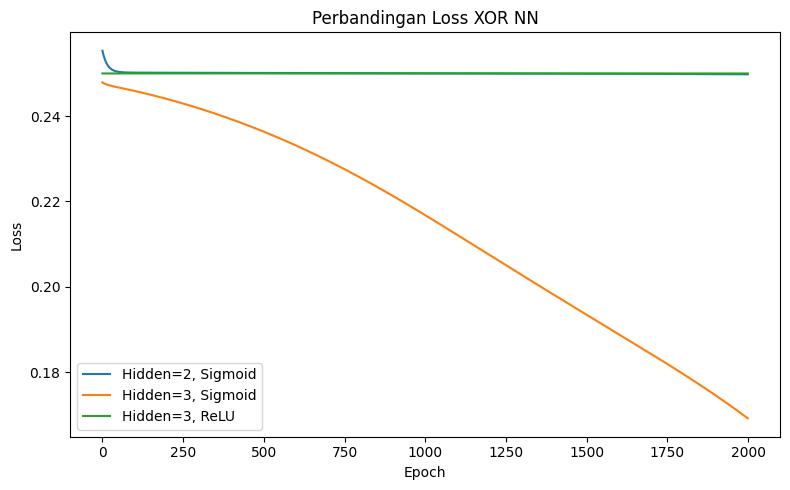

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# Activation functions
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def sigmoid_der(x):
    return x * (1 - x)

def relu(x):
    return np.maximum(0, x)

def relu_der(x):
    return (x > 0).astype(float)

# Training function
def train(hidden_size, activation="sigmoid"):
    # Dataset XOR
    X = np.array([[0,0],[0,1],[1,0],[1,1]])
    y = np.array([[0],[1],[1],[0]])

    lr = 0.1

    # Inisialisasi bobot
    W1 = np.random.randn(2, hidden_size)
    b1 = np.zeros((1, hidden_size))
    W2 = np.random.randn(hidden_size, 1)
    b2 = np.zeros((1, 1))

    losses = []

    for epoch in range(2000):
        # Forward
        z1 = X.dot(W1) + b1

        # pilih aktivasi
        if activation == "sigmoid":
            a1 = sigmoid(z1)
            d1 = sigmoid_der(a1)
        else:
            a1 = relu(z1)
            d1 = relu_der(z1)

        z2 = a1.dot(W2) + b2
        a2 = sigmoid(z2)

        # Error
        error = y - a2
        losses.append(np.mean(error**2))

        # Backprop
        d2 = error * sigmoid_der(a2)

        # Update W2, b2
        W2 += lr * a1.T.dot(d2)
        b2 += lr * np.sum(d2, keepdims=True)

        # Hidden
        d1_full = d2.dot(W2.T) * d1
        W1 += lr * X.T.dot(d1_full)
        b1 += lr * np.sum(d1_full, axis=0, keepdims=True)

    return losses

# Train tiga model
loss_2_sigmoid = train(2, "sigmoid")
loss_3_sigmoid = train(3, "sigmoid")
loss_3_relu    = train(3, "relu")

# === Plot Visualisasi ===
plt.figure(figsize=(8,5))

plt.plot(loss_2_sigmoid, label="Hidden=2, Sigmoid")
plt.plot(loss_3_sigmoid, label="Hidden=3, Sigmoid")
plt.plot(loss_3_relu,    label="Hidden=3, ReLU")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Perbandingan Loss XOR NN")
plt.legend()
plt.tight_layout()
plt.show()


# PRAKTIKUM 2

In [5]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
import tensorflow as tf

# Load dataset
iris = load_iris()
X = iris.data
y = iris.target.reshape(-1, 1)

# One-hot encoding
encoder = OneHotEncoder(sparse_output=False)
y = encoder.fit_transform(y)

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Bangun model
model = tf.keras.Sequential([
    tf.keras.layers.Dense(10, activation='relu', input_shape=(4,)),
    tf.keras.layers.Dense(8, activation='relu'),
    tf.keras.layers.Dense(3, activation='softmax')
])

# Kompilasi
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Latih model
model.fit(X_train, y_train, epochs=50, batch_size=8)

# Evaluasi
loss, acc = model.evaluate(X_test, y_test)
print(f"Akurasi: {acc}")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.3057 - loss: 1.3473
Epoch 2/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.2898 - loss: 1.2446
Epoch 3/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.3947 - loss: 1.1075
Epoch 4/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.6655 - loss: 0.9781
Epoch 5/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6130 - loss: 0.9456 
Epoch 6/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.6363 - loss: 0.8823
Epoch 7/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6579 - loss: 0.8674
Epoch 8/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7138 - loss: 0.8175
Epoch 9/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6549 - loss: 0.8136
Epoch 10/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6948 - loss: 0.7724
Epoch 11/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7564 - loss: 0.7490
Epoch 12/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.695

# TUGAS 2

In [8]:
# Ubah jumlah neuron hidden layer
# Bandingkan akurasi dengan konfigurasi awal
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
import tensorflow as tf
import numpy as np

# Load dataset
iris = load_iris()
X = iris.data
y = iris.target.reshape(-1, 1)

# One-hot encoding
encoder = OneHotEncoder(sparse_output=False)
y = encoder.fit_transform(y)

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Fungsi untuk membangun dan melatih model
def run_model(n1, n2):
    model = tf.keras.Sequential([
        tf.keras.layers.Dense(n1, activation='relu', input_shape=(4,)),
        tf.keras.layers.Dense(n2, activation='relu'),
        tf.keras.layers.Dense(3, activation='softmax')
    ])

    model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    model.fit(X_train, y_train, epochs=50, batch_size=8, verbose=0)

    loss, acc = model.evaluate(X_test, y_test, verbose=0)
    return acc

# Konfigurasi yang mau dibandingkan
configs = [
    (10, 8),   # konfigurasi awal
    (16, 8),
    (32, 16),
    (8, 4),
    (4, 4)
]

print("=== HASIL PERBANDINGAN AKURASI ===")
for n1, n2 in configs:
    acc = run_model(n1, n2)
    print(f"Hidden=({n1}, {n2}) -> Akurasi = {acc:.4f}")

=== HASIL PERBANDINGAN AKURASI ===


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Hidden=(10, 8) -> Akurasi = 0.9667
Hidden=(16, 8) -> Akurasi = 1.0000
Hidden=(32, 16) -> Akurasi = 0.9667
Hidden=(8, 4) -> Akurasi = 0.3333
Hidden=(4, 4) -> Akurasi = 0.8667


# TUGAS 3

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


=== HASIL PERBANDINGAN ===
Sigmoid -> Loss: 0.6853, Akurasi: 0.8000
ReLU    -> Loss: 0.3758, Akurasi: 0.9667


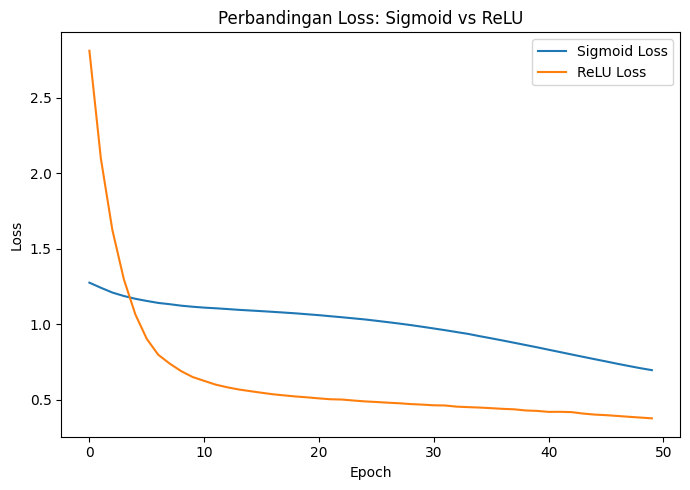

In [10]:
# Bandingkan Sigmoid vs ReLU
# Catat perbedaan loss dan akurasi

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
import tensorflow as tf
import numpy as np

# Load dataset
iris = load_iris()
X = iris.data
y = iris.target.reshape(-1, 1)

# One-hot encoding
encoder = OneHotEncoder(sparse_output=False)
y = encoder.fit_transform(y)

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Fungsi untuk melatih model dgn aktivasi tertentu
def run_model(activation):
    model = tf.keras.Sequential([
        tf.keras.layers.Dense(10, activation=activation, input_shape=(4,)),
        tf.keras.layers.Dense(8, activation=activation),
        tf.keras.layers.Dense(3, activation='softmax')
    ])

    model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    history = model.fit(
        X_train, y_train,
        epochs=50, batch_size=8, verbose=0
    )

    loss, acc = model.evaluate(X_test, y_test, verbose=0)
    return history, loss, acc

# Jalankan kedua model
history_sig, loss_sig, acc_sig = run_model("sigmoid")
history_relu, loss_relu, acc_relu = run_model("relu")

# Print hasil
print("=== HASIL PERBANDINGAN ===")
print(f"Sigmoid -> Loss: {loss_sig:.4f}, Akurasi: {acc_sig:.4f}")
print(f"ReLU    -> Loss: {loss_relu:.4f}, Akurasi: {acc_relu:.4f}")

# Visualisasi loss
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))
plt.plot(history_sig.history["loss"], label="Sigmoid Loss")
plt.plot(history_relu.history["loss"], label="ReLU Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Perbandingan Loss: Sigmoid vs ReLU")
plt.legend()
plt.tight_layout()
plt.show()

# PRAKTIKUM 3

In [11]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import tensorflow as tf

# Contoh dataset (buat dummy data)
data = pd.DataFrame({
    'luas': [50, 60, 70, 80, 90],
    'harga': [500, 600, 700, 800, 900]
})

X = data[['luas']]
y = data[['harga']]

# Normalisasi
scaler = StandardScaler()
X = scaler.fit_transform(X)
y = scaler.fit_transform(y)

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Model
model = tf.keras.Sequential([
    tf.keras.layers.Dense(10, activation='relu', input_shape=(1,)),
    tf.keras.layers.Dense(1)
])

model.compile(optimizer='adam', loss='mse')
model.fit(X_train, y_train, epochs=100)

# Evaluasi
print("Prediksi:", model.predict(X_test))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 945ms/step - loss: 0.8522
Epoch 2/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - loss: 0.8429
Epoch 3/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - loss: 0.8336
Epoch 4/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - loss: 0.8244
Epoch 5/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - loss: 0.8153
Epoch 6/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - loss: 0.8062
Epoch 7/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step - loss: 0.7972
Epoch 8/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - loss: 0.7882
Epoch 9/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - loss: 0.7792
Epoch 10/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - loss: 0.7704
Epoch 11/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - loss: 0.7616
Epoch 12/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - loss: 0.7528
Epoch 13/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - loss: 0.7441
Epoch 14/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - loss: 0.7355
Epoch 15/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - loss: 0.7269
Epoch 16/100
1/1 

# TUGAS 4

In [12]:
# Ubah learning rate
# Bandingkan hasil loss
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import tensorflow as tf

# 1. Dataset (dummy data)
data = pd.DataFrame({
    'luas': [50, 60, 70, 80, 90],
    'harga': [500, 600, 700, 800, 900]
})

X = data[['luas']]
y = data[['harga']]

# Normalisasi
scaler_x = StandardScaler()
scaler_y = StandardScaler()

X = scaler_x.fit_transform(X)
y = scaler_y.fit_transform(y)

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# 2. Fungsi membuat & melatih model

def train_model(lr):
    model = tf.keras.Sequential([
        tf.keras.layers.Dense(10, activation='relu', input_shape=(1,)),
        tf.keras.layers.Dense(1)
    ])

    optimizer = tf.keras.optimizers.Adam(learning_rate=lr)

    model.compile(optimizer=optimizer, loss='mse')

    history = model.fit(X_train, y_train, epochs=100, verbose=0)
    final_loss = history.history['loss'][-1]

    return final_loss

# 3. Uji beberapa learning rate

learning_rates = [0.1, 0.01, 0.001]
loss_results = {}

for lr in learning_rates:
    print(f"Training dengan learning rate = {lr}")
    loss_results[lr] = train_model(lr)

print("\n=== HASIL PERBANDINGAN LOSS ===")
for lr, loss in loss_results.items():
    print(f"Learning Rate {lr} --> Loss: {loss}")


Training dengan learning rate = 0.1


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Training dengan learning rate = 0.01
Training dengan learning rate = 0.001

=== HASIL PERBANDINGAN LOSS ===
Learning Rate 0.1 --> Loss: 4.271287252777256e-05
Learning Rate 0.01 --> Loss: 0.0013967702398076653
Learning Rate 0.001 --> Loss: 0.5230986475944519


# Menggunakan data boston

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


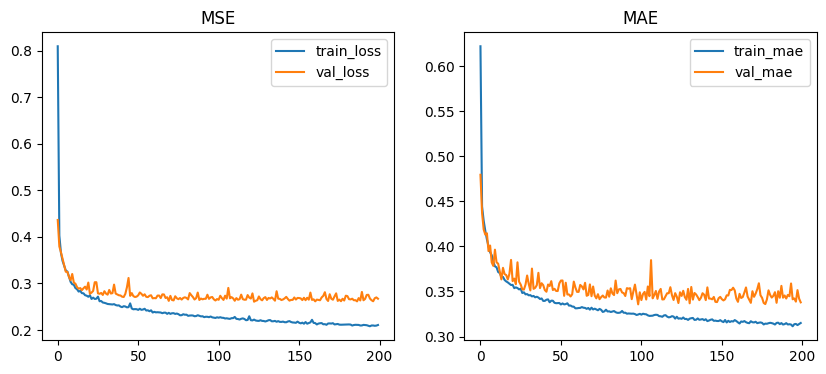

129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
RMSE: 0.5168694321948576


In [14]:
# MLP regresi (Keras)
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing # Changed from load_boston
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam

# 1. Load
data = fetch_california_housing() # Changed from load_boston()
X = data.data; y = data.target

# 2. Preprocess
scaler = StandardScaler(); Xs = scaler.fit_transform(X)
X_train, X_val, y_train, y_val = train_test_split(Xs, y, test_size=0.2, random_state=42)

# 3. Build model
model = Sequential([
Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
Dense(32, activation='relu'),
Dense(1)
])
model.compile(optimizer=Adam(1e-3), loss='mse', metrics=['mae'])

# 4. Train
h = model.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=200, batch_size=32, verbose=0)

# 5. Plot
plt.figure(figsize=(10,4))
plt.subplot(1,2,1); plt.plot(h.history['loss'], label='train_loss'); plt.plot(h.history['val_loss'], label='val_loss'); plt.legend(); plt.title('MSE')
plt.subplot(1,2,2); plt.plot(h.history['mae'], label='train_mae'); plt.plot(h.history['val_mae'], label='val_mae'); plt.legend(); plt.title('MAE')
plt.show()

from sklearn.metrics import mean_squared_error
pred = model.predict(X_val)
print('RMSE:', np.sqrt(mean_squared_error(y_val, pred)))

# TUGAS PRAKTIKUM

In [16]:
import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.utils import to_categorical

# 1. Load dataset MNIST
(X_train, y_train), (X_test, y_test) = mnist.load_data()

# Normalisasi data (0-255 → 0-1)
X_train = X_train / 255.0
X_test = X_test / 255.0

# One-hot encoding label
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

# 2. Bangun model JST
model = Sequential([
    # Ubah gambar 28x28 menjadi vektor
    Flatten(input_shape=(28, 28)),
    # Hidden layer 1
    tf.keras.layers.Dense(128, activation='relu'),
    # Hidden layer 2
    tf.keras.layers.Dense(64, activation='relu'),
    # Output layer (10 kelas)
    tf.keras.layers.Dense(10, activation='softmax')
])

# 3. Kompilasi model
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# 4. Latih model
model.fit(X_train, y_train, epochs=10, batch_size=32, verbose=1)

# 5. Evaluasi model
loss, acc = model.evaluate(X_test, y_test, verbose=0)
print(f"Akurasi pada data uji: {acc:.4f}")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.8733 - loss: 0.4322
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9688 - loss: 0.1059
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9787 - loss: 0.0693
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9836 - loss: 0.0518
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9885 - loss: 0.0367
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9898 - loss: 0.0343
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.9919 - loss: 0.0260
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.9934 - loss: 0.0206
Epoch 9/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9933 - loss: 0.0192
Epoch 10/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9943 - loss: 0.0164
Akurasi pada data uji: 0.9782


**Coba dengan beberapa parameter lain:**

**Ubah jumlah neuron di hidden layer (misal: 256 dan 128).**

**Tambahkan satu hidden layer lagi.**

**Bandingkan akurasi dan waktu pelatihan.**

**Eksperimen dengan fungsi aktivasi Sigmoid vs ReLU.**

In [17]:
import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.utils import to_categorical
import time

# 1. Load & Preprocessing Dataset
(X_train, y_train), (X_test, y_test) = mnist.load_data()
X_train, X_test = X_train/255.0, X_test/255.0

y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

# Fungsi untuk membangun model

def build_model(activation="relu", units1=128, units2=64, extra_layer=False):
    model = Sequential()
    model.add(Flatten(input_shape=(28, 28)))
    model.add(Dense(units1, activation=activation))

    if extra_layer:
        model.add(Dense(128, activation=activation))  # hidden tambahan

    model.add(Dense(units2, activation=activation))
    model.add(Dense(10, activation="softmax"))

    model.compile(optimizer="adam",
                  loss="categorical_crossentropy",
                  metrics=["accuracy"])
    return model

# Fungsi menjalankan eksperimen

def run_experiment(name, activation, units1, units2, extra_layer=False):
    print(f"\n=== {name} ===")
    model = build_model(
        activation=activation,
        units1=units1,
        units2=units2,
        extra_layer=extra_layer
    )

    start = time.time()
    history = model.fit(
        X_train, y_train,
        epochs=5,
        batch_size=32,
        verbose=0
    )
    duration = time.time() - start

    loss, acc = model.evaluate(X_test, y_test, verbose=0)
    print(f"Akurasi: {acc:.4f}, Loss: {loss:.4f}, Waktu: {duration:.2f} detik")

    return acc, loss, duration

# 2. EKSPERIMEN

# A. ReLU (default)
run_experiment(
    name="Model ReLU (128–64)",
    activation="relu",
    units1=128,
    units2=64
)

# B. Sigmoid (default)
run_experiment(
    name="Model Sigmoid (128–64)",
    activation="sigmoid",
    units1=128,
    units2=64
)

# C. ReLU dengan neuron besar
run_experiment(
    name="Model ReLU (256–128)",
    activation="relu",
    units1=256,
    units2=128
)

# D. Tambah Hidden Layer ReLU
run_experiment(
    name="Model ReLU + Extra Layer (128–128–64)",
    activation="relu",
    units1=128,
    units2=64,
    extra_layer=True
)



=== Model ReLU (128–64) ===


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Akurasi: 0.9779, Loss: 0.0741, Waktu: 40.91 detik

=== Model Sigmoid (128–64) ===
Akurasi: 0.9750, Loss: 0.0862, Waktu: 39.18 detik

=== Model ReLU (256–128) ===
Akurasi: 0.9793, Loss: 0.0760, Waktu: 66.23 detik

=== Model ReLU + Extra Layer (128–128–64) ===
Akurasi: 0.9683, Loss: 0.1092, Waktu: 43.63 detik


(0.9682999849319458, 0.10916586965322495, 43.63268232345581)